In [1]:
# =============================================================
# CELLULE 1 — IMPORTS ET CONFIGURATION
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Split & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sérialisation
import joblib
from pathlib import Path

# Seed pour la reproductibilité
SEED = 42
np.random.seed(SEED)

# Style des graphiques
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"]      = 12

# Options d'affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",    100)
pd.set_option("display.precision",   2)

# Dossiers de sortie
DATA_PROC = Path("../data/processed")
ARTIFACTS = Path("../artifacts")
DATA_PROC.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

print("✓ Environnement configuré avec succès.")

✓ Environnement configuré avec succès.


In [2]:
# =============================================================
# CELLULE 2 — CHARGEMENT DU DATASET NETTOYÉ
# =============================================================

# On repart du fichier produit par le NB01 (nettoyage structurel).
# Il contient encore : encounter_id, patient_nbr, readmitted (brute)
# et des NaN → tout est géré ici.
# APRÈS : on force les 3 identifiants à être lus comme du texte
# (le CSV ne conserve pas le type ; sans ça ils reviennent en int64)
df = pd.read_csv(
    DATA_PROC / "data_features.csv",
    dtype={
        "discharge_disposition_id": str,
        "admission_type_id": str,
        "admission_source_id": str,
    },
)

print("=" * 50)
print("DATASET chargé")
print("=" * 50)
print(f"  Lignes   : {df.shape[0]:,}")
print(f"  Colonnes : {df.shape[1]}")

# --- Contrôles de cohérence : le NB01 doit avoir fait son travail ---
assert df["patient_nbr"].is_unique, "❌ Doublons patients ! Relance le NB01."
assert "readmitted_binary" in df.columns, "❌ Cible binaire absente ! Relance le NB01."
assert df["readmitted_binary"].isin([0, 1]).all(), "❌ Cible non binaire !"

print(f"\n✓ Contrôles NB01 OK.")
print(f"  Taux de positifs : {df['readmitted_binary'].mean()*100:.2f}%")

DATASET chargé
  Lignes   : 69,987
  Colonnes : 52

✓ Contrôles NB01 OK.
  Taux de positifs : 8.98%


In [3]:
# DIAGNOSTIC : vérifier que les 3 ids sont bien en texte (object)
for col in ["discharge_disposition_id", "admission_type_id", "admission_source_id"]:
    print(f"{col} : type = {df[col].dtype}")

discharge_disposition_id : type = str
admission_type_id : type = str
admission_source_id : type = str


In [4]:
# =============================================================
# CELLULE 3 — DÉFINITION DE X ET y
# =============================================================

# Colonnes à NE PAS utiliser comme features :
#   - identifiants (leakage évident)
#   - cible brute + cible binaire
DROP_COLS = ["encounter_id", "patient_nbr", "readmitted", "readmitted_binary"]
TARGET    = "readmitted_binary"

# On ne garde que les colonnes réellement présentes (robustesse)
drop_present = [c for c in DROP_COLS if c in df.columns]

y = df[TARGET].copy()
X = df.drop(columns=drop_present).copy()

print("=" * 50)
print("SÉPARATION X / y")
print("=" * 50)
print(f"  Features (X) : {X.shape[1]} colonnes")
print(f"  Cible (y)    : {len(y):,} labels")
print(f"\n  Colonnes exclues des features : {drop_present}")

SÉPARATION X / y
  Features (X) : 48 colonnes
  Cible (y)    : 69,987 labels

  Colonnes exclues des features : ['encounter_id', 'patient_nbr', 'readmitted', 'readmitted_binary']


In [5]:
# =============================================================
# CELLULE 4 — SPLIT TRAIN / VAL / TEST (70 / 15 / 15)
# =============================================================

# Le split se fait AVANT tout preprocessing → aucun fit n'a encore
# eu lieu, donc aucune information de val/test ne peut fuiter.
# Stratification sur la cible pour préserver le ratio ~11% de positifs.
# Rappel : 1 seul séjour par patient (NB01) → pas de fuite inter-patient.

# 1er split : train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

# 2e split : temp (30%) → val (15%) + test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 50% de 30% = 15%
    stratify=y_temp,
    random_state=SEED,
)

print("=" * 50)
print("RÉPARTITION DES ENSEMBLES")
print("=" * 50)
for nom, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {nom:<6} : {len(yy):>6,} lignes  ({len(yy)/len(y)*100:>4.1f}%)  "
          f"— {yy.mean()*100:.2f}% positifs")

# --- Contrôle anti-leakage : aucun index partagé ---
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
print("\n✓ Aucun index partagé entre train / val / test.")

RÉPARTITION DES ENSEMBLES
  Train  : 48,990 lignes  (70.0%)  — 8.98% positifs
  Val    : 10,498 lignes  (15.0%)  — 8.98% positifs
  Test   : 10,499 lignes  (15.0%)  — 8.98% positifs

✓ Aucun index partagé entre train / val / test.


In [6]:
# =============================================================
# CELLULE 5 — TYPES DE COLONNES (numériques / catégorielles)
# =============================================================

# On détermine les types à partir de X_train UNIQUEMENT
# (on n'apprend rien du val/test, même pas la liste des colonnes).
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("=" * 50)
print("TYPES DE VARIABLES")
print("=" * 50)
print(f"  Numériques   : {len(num_features)}")
print(f"  Catégorielles: {len(cat_features)}")

print(f"\n  → Numériques : {num_features}")
print(f"\n  → Catégorielles : {cat_features}")

TYPES DE VARIABLES
  Numériques   : 40
  Catégorielles: 8

  → Numériques : ['gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'age_numeric', 'age_group', 'score_risque_hospitalier', 'ratio_medicaments_procedures', 'patient_complexe', 'A1C_mesure', 'glucose_mesure']

  → Catégorielles : ['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']


C:\Users\malek\AppData\Local\Temp\ipykernel_21172\4012369521.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()


In [7]:
# =============================================================
# CELLULE 6 — PIPELINE DE PREPROCESSING (scikit-learn)
# =============================================================

# --- Pipeline numérique : imputation médiane + standardisation ---
# median : robuste aux distributions asymétriques (cf. number_inpatient…)
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# --- Pipeline catégoriel : imputation "missing" + One-Hot ---
# fill_value="missing" : les NaN (medical_specialty, race…) deviennent
#   une modalité explicite plutôt que d'être devinés.
# handle_unknown="ignore" : robustesse si une modalité rare n'apparaît
#   qu'en val/test → vecteur de zéros au lieu d'une erreur.
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Assemblage ---
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
], remainder="drop")

print("✓ Pipeline de preprocessing construit.")
print("  num → SimpleImputer(median) + StandardScaler")
print("  cat → SimpleImputer('missing') + OneHotEncoder(ignore)")

✓ Pipeline de preprocessing construit.
  num → SimpleImputer(median) + StandardScaler
  cat → SimpleImputer('missing') + OneHotEncoder(ignore)


In [8]:
# =============================================================
# CELLULE 7 — FIT (train) puis TRANSFORM (train / val / test)
# =============================================================

# fit_transform UNIQUEMENT sur le train : le scaler et l'imputer
# n'apprennent que des statistiques du train.
X_train_proc = preprocessor.fit_transform(X_train)

# transform SEULEMENT sur val et test (aucun fit).
X_val_proc  = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Récupération des noms de colonnes après One-Hot
feature_names = preprocessor.get_feature_names_out()

print("=" * 50)
print("SHAPES APRÈS PREPROCESSING")
print("=" * 50)
print(f"  X_train : {X_train_proc.shape}")
print(f"  X_val   : {X_val_proc.shape}")
print(f"  X_test  : {X_test_proc.shape}")
print(f"\n  Features après One-Hot : {len(feature_names)}")

# --- Reconversion en DataFrame (lisibilité + compatibilité SHAP au NB06) ---
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_val_proc   = pd.DataFrame(X_val_proc,   columns=feature_names, index=X_val.index)
X_test_proc  = pd.DataFrame(X_test_proc,  columns=feature_names, index=X_test.index)

SHAPES APRÈS PREPROCESSING
  X_train : (48990, 186)
  X_val   : (10498, 186)
  X_test  : (10499, 186)

  Features après One-Hot : 186


In [9]:
# =============================================================
# CELLULE 8 — CONTRÔLE ANTI-LEAKAGE
# =============================================================

# Après standardisation, la moyenne des features numériques du TRAIN
# doit être ≈ 0. Sur val/test elle N'EST PAS forcément 0 → c'est le
# signe qu'on a bien fait transform (et non fit) sur ces ensembles.

num_cols_proc = [f"num__{c}" for c in num_features]

moy_train = X_train_proc[num_cols_proc].mean().abs().mean()
moy_val   = X_val_proc[num_cols_proc].mean().abs().mean()
moy_test  = X_test_proc[num_cols_proc].mean().abs().mean()

print("=" * 50)
print("VÉRIFICATION DU SCALING")
print("=" * 50)
print(f"  |moyenne| features num — train : {moy_train:.2e}  (attendu ≈ 0)")
print(f"  |moyenne| features num — val   : {moy_val:.4f}   (≠ 0 = normal)")
print(f"  |moyenne| features num — test  : {moy_test:.4f}   (≠ 0 = normal)")

assert moy_train < 1e-6, "❌ Moyenne train ≠ 0 : problème de scaling."
print("\n✓ Le preprocessing a bien été fit sur le TRAIN uniquement.")

VÉRIFICATION DU SCALING
  |moyenne| features num — train : 4.89e-17  (attendu ≈ 0)
  |moyenne| features num — val   : 0.0087   (≠ 0 = normal)
  |moyenne| features num — test  : 0.0096   (≠ 0 = normal)

✓ Le preprocessing a bien été fit sur le TRAIN uniquement.


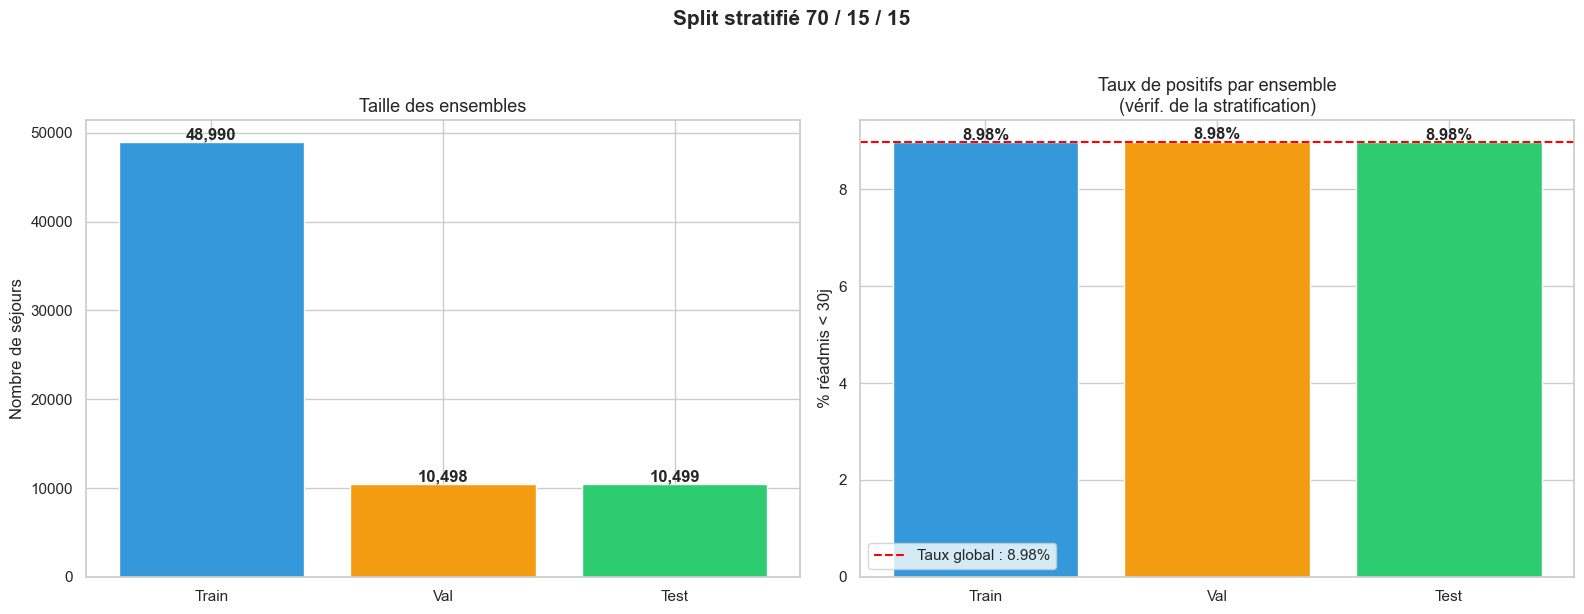

In [10]:
# =============================================================
# CELLULE 9 — VISUALISATION DU SPLIT
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : taille des ensembles ---
noms    = ["Train", "Val", "Test"]
tailles = [len(y_train), len(y_val), len(y_test)]
couleurs = ["#3498DB", "#F39C12", "#2ECC71"]

bars = axes[0].bar(noms, tailles, color=couleurs, edgecolor="white")
for bar, val in zip(bars, tailles):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f"{val:,}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Taille des ensembles", fontsize=13)
axes[0].set_ylabel("Nombre de séjours")

# --- Graphique 2 : taux de positifs (vérif de la stratification) ---
taux = [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100]
bars = axes[1].bar(noms, taux, color=couleurs, edgecolor="white")
for bar, val in zip(bars, taux):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05,
                 f"{val:.2f}%", ha="center", fontsize=12, fontweight="bold")
axes[1].axhline(y.mean()*100, ls="--", color="red", linewidth=1.5,
                label=f"Taux global : {y.mean()*100:.2f}%")
axes[1].set_title("Taux de positifs par ensemble\n(vérif. de la stratification)", fontsize=13)
axes[1].set_ylabel("% réadmis < 30j")
axes[1].legend()

plt.suptitle("Split stratifié 70 / 15 / 15", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# =============================================================
# CELLULE 10 — SÉRIALISATION DES SORTIES
# =============================================================

# --- Jeux de données (X preprocessés + y) ---
datasets = {
    "X_train": X_train_proc, "X_val": X_val_proc, "X_test": X_test_proc,
    "y_train": y_train,      "y_val": y_val,      "y_test": y_test,
}
for nom, obj in datasets.items():
    obj.to_pickle(DATA_PROC / f"{nom}.pkl")

# --- Pipeline fitté (réutilisé au NB07 pour l'inférence) ---
joblib.dump(preprocessor, ARTIFACTS / "preprocessor.pkl")

print("=" * 50)
print("NB02 TERMINÉ — SPLIT + PREPROCESSING")
print("=" * 50)
print(f"  Train : {len(y_train):>6,} lignes ({y_train.mean()*100:.1f}% pos)")
print(f"  Val   : {len(y_val):>6,} lignes ({y_val.mean()*100:.1f}% pos)")
print(f"  Test  : {len(y_test):>6,} lignes ({y_test.mean()*100:.1f}% pos)")
print(f"  Features finales : {len(feature_names)}")
print("\n  Fichiers écrits :")
print(f"    {DATA_PROC}/X_train.pkl, X_val.pkl, X_test.pkl")
print(f"    {DATA_PROC}/y_train.pkl, y_val.pkl, y_test.pkl")
print(f"    {ARTIFACTS}/preprocessor.pkl")
print("=" * 50)
print("\n➡️  Prochaine étape : NB05 — MODELISATION")

NB02 TERMINÉ — SPLIT + PREPROCESSING
  Train : 48,990 lignes (9.0% pos)
  Val   : 10,498 lignes (9.0% pos)
  Test  : 10,499 lignes (9.0% pos)
  Features finales : 186

  Fichiers écrits :
    ..\data\processed/X_train.pkl, X_val.pkl, X_test.pkl
    ..\data\processed/y_train.pkl, y_val.pkl, y_test.pkl
    ..\artifacts/preprocessor.pkl

➡️  Prochaine étape : NB05 — MODELISATION


# NB04 — Split & Preprocessing

## Objectif
Split train/val/test puis preprocessing qui **apprend des statistiques**
(imputation, scaling, One-Hot), **fit sur le train uniquement** (anti-leakage).

## Étapes
1. **Split stratifié 70/15/15** sur la cible (~9% positifs préservés)
2. **Pipeline `ColumnTransformer`** — num : imputation médiane + StandardScaler ;
   cat : imputation "missing" + OneHotEncoder(handle_unknown="ignore")
3. **Encodage catégoriel des 3 identifiants** (`discharge_disposition_id`,
   `admission_type_id`, `admission_source_id`), forcés en texte au chargement
   (`dtype=str`) car ce sont des codes, pas des quantités.

## Résultats
- Train 48 990 | Val 10 498 | Test 10 499 — **8,98% positifs** dans les 3 ensembles
- **186 features** après One-Hot (vs 144 avant la correction des identifiants)
- Scaling vérifié : moyenne train ≈ 0 (4,9e-17), val/test ≠ 0 → fit sur train seul

## Sorties
`X_{train,val,test}.pkl`, `y_{train,val,test}.pkl`, `preprocessor.pkl`